In [146]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import joblib

In [94]:
df=pd.read_csv("customer.csv")
df

,user_id,age,annual_income,spending_score,gender,region
0,1,25,30000.0,40.0,Male,South
1,2,NaN,45000.0,60.0,Female,North
2,3,35,50000.0,NaN,Male,West
3,4,22,20000.0,30.0,Female,South
4,5,27,35000.0,50.0,Male,East
5,6,thirty,70000.0,80.0,Female,North
6,7,45,120000.0,95.0,Male,West
7,8,21,18000.0,20.0,Female,South
8,9,29,40000.0,55.0,Male,East
9,10,31,42000.0,60.0,Female,North


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         17 non-null     int64  
 1   age             15 non-null     str    
 2   annual_income   16 non-null     float64
 3   spending_score  16 non-null     float64
 4   gender          17 non-null     str    
 5   region          17 non-null     str    
dtypes: float64(2), int64(1), str(3)
memory usage: 948.0 bytes


In [96]:
df.head()

,user_id,age,annual_income,spending_score,gender,region
0,1,25,30000.0,40.0,Male,South
1,2,NaN,45000.0,60.0,Female,North
2,3,35,50000.0,NaN,Male,West
3,4,22,20000.0,30.0,Female,South
4,5,27,35000.0,50.0,Male,East


In [99]:
df.isnull().sum()

user_id           0
age               2
annual_income     1
spending_score    1
gender            0
region            0
dtype: int64

In [101]:
df["age"]=pd.to_numeric(df["age"],errors="coerce")

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         17 non-null     int64  
 1   age             14 non-null     float64
 2   annual_income   16 non-null     float64
 3   spending_score  16 non-null     float64
 4   gender          17 non-null     str    
 5   region          17 non-null     str    
dtypes: float64(3), int64(1), str(2)
memory usage: 948.0 bytes


In [103]:
df.isnull().sum()

user_id           0
age               3
annual_income     1
spending_score    1
gender            0
region            0
dtype: int64

In [104]:
df["age"]=df["age"].fillna(df["age"].mean())
df["spending_score"]=df["spending_score"].fillna(df["spending_score"].median())
df["annual_income"]=df["annual_income"].fillna(df["annual_income"].median())

In [105]:
df

,user_id,age,annual_income,spending_score,gender,region
0,1,25.0,30000.0,40.0,Male,South
1,2,30.0,45000.0,60.0,Female,North
2,3,35.0,50000.0,52.5,Male,West
3,4,22.0,20000.0,30.0,Female,South
4,5,27.0,35000.0,50.0,Male,East
5,6,30.0,70000.0,80.0,Female,North
6,7,45.0,120000.0,95.0,Male,West
7,8,21.0,18000.0,20.0,Female,South
8,9,29.0,40000.0,55.0,Male,East
9,10,31.0,42000.0,60.0,Female,North


In [106]:
df=df.drop("user_id",axis=1)

In [108]:
df=df.drop_duplicates()
df

,age,annual_income,spending_score,gender,region
0,25.0,30000.0,40.0,Male,South
1,30.0,45000.0,60.0,Female,North
2,35.0,50000.0,52.5,Male,West
3,22.0,20000.0,30.0,Female,South
4,27.0,35000.0,50.0,Male,East
5,30.0,70000.0,80.0,Female,North
6,45.0,120000.0,95.0,Male,West
7,21.0,18000.0,20.0,Female,South
8,29.0,40000.0,55.0,Male,East
9,31.0,42000.0,60.0,Female,North


In [109]:
df.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 0 to 16
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             16 non-null     float64
 1   annual_income   16 non-null     float64
 2   spending_score  16 non-null     float64
 3   gender          16 non-null     str    
 4   region          16 non-null     str    
dtypes: float64(3), str(2)
memory usage: 768.0 bytes


In [111]:
df["age"]=df["age"].astype(int)
df["spending_score"]=df["spending_score"].astype(int)
df

,age,annual_income,spending_score,gender,region
0,25,30000.0,40,Male,South
1,30,45000.0,60,Female,North
2,35,50000.0,52,Male,West
3,22,20000.0,30,Female,South
4,27,35000.0,50,Male,East
5,30,70000.0,80,Female,North
6,45,120000.0,95,Male,West
7,21,18000.0,20,Female,South
8,29,40000.0,55,Male,East
9,31,42000.0,60,Female,North


In [113]:
Q1=df["annual_income"].quantile(0.25)
Q3=df["annual_income"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["annual_income"]>=lower)&(df["annual_income"]<=upper)]
df

,age,annual_income,spending_score,gender,region
0,25,30000.0,40,Male,South
1,30,45000.0,60,Female,North
2,35,50000.0,52,Male,West
3,22,20000.0,30,Female,South
4,27,35000.0,50,Male,East
5,30,70000.0,80,Female,North
7,21,18000.0,20,Female,South
8,29,40000.0,55,Male,East
9,31,42000.0,60,Female,North
10,30,39000.0,50,Male,South


In [114]:
df=pd.get_dummies(df,columns=["gender","region"])
df

,age,annual_income,spending_score,gender_Female,gender_Male,region_East,region_North,region_South,region_West
0,25,30000.0,40,False,True,False,False,True,False
1,30,45000.0,60,True,False,False,True,False,False
2,35,50000.0,52,False,True,False,False,False,True
3,22,20000.0,30,True,False,False,False,True,False
4,27,35000.0,50,False,True,True,False,False,False
5,30,70000.0,80,True,False,False,True,False,False
7,21,18000.0,20,True,False,False,False,True,False
8,29,40000.0,55,False,True,True,False,False,False
9,31,42000.0,60,True,False,False,True,False,False
10,30,39000.0,50,False,True,False,False,True,False


In [115]:
df.info()

<class 'pandas.DataFrame'>
Index: 14 entries, 0 to 14
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             14 non-null     int64  
 1   annual_income   14 non-null     float64
 2   spending_score  14 non-null     int64  
 3   gender_Female   14 non-null     bool   
 4   gender_Male     14 non-null     bool   
 5   region_East     14 non-null     bool   
 6   region_North    14 non-null     bool   
 7   region_South    14 non-null     bool   
 8   region_West     14 non-null     bool   
dtypes: bool(6), float64(1), int64(2)
memory usage: 532.0 bytes


In [119]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)
x_scaled

array([[-0.75448765, -0.61954327, -0.69733575, -1.        ,  1.        ,
        -0.52223297, -0.63245553,  1.34164079, -0.40824829],
       [ 0.53366199,  0.5369375 ,  0.58723011,  1.        , -1.        ,
        -0.52223297,  1.58113883, -0.74535599, -0.40824829],
       [ 1.82181163,  0.92243109,  0.07340376, -1.        ,  1.        ,
        -0.52223297, -0.63245553, -0.74535599,  2.44948974],
       [-1.52737743, -1.39053045, -1.33961868,  1.        , -1.        ,
        -0.52223297, -0.63245553,  1.34164079, -0.40824829],
       [-0.23922779, -0.23404968, -0.05505282, -1.        ,  1.        ,
         1.91485422, -0.63245553, -0.74535599, -0.40824829],
       [ 0.53366199,  2.46440546,  1.87179597,  1.        , -1.        ,
        -0.52223297,  1.58113883, -0.74535599, -0.40824829],
       [-1.78500736, -1.54472789, -1.98190161,  1.        , -1.        ,
        -0.52223297, -0.63245553,  1.34164079, -0.40824829],
       [ 0.27603207,  0.15144391,  0.26608864, -1.        ,  1

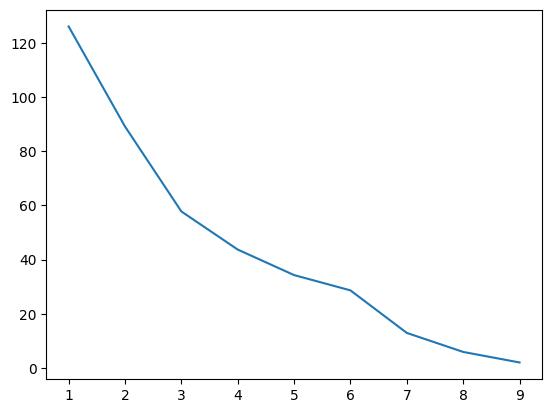

In [122]:
#elbow method is to find the best k
inertia=[]
for k in range(1,10):
    model=KMeans(n_clusters=k)
    model.fit(x_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1,10),inertia)
plt.show()

In [142]:
model=KMeans(n_clusters=4)
clusters=model.fit_predict(x_scaled)
df["clusters"]=clusters
df

,age,annual_income,spending_score,gender_Female,gender_Male,region_East,region_North,region_South,region_West,clusters
0,25,30000.0,40,False,True,False,False,True,False,1
1,30,45000.0,60,True,False,False,True,False,False,0
2,35,50000.0,52,False,True,False,False,False,True,3
3,22,20000.0,30,True,False,False,False,True,False,1
4,27,35000.0,50,False,True,True,False,False,False,2
5,30,70000.0,80,True,False,False,True,False,False,0
7,21,18000.0,20,True,False,False,False,True,False,1
8,29,40000.0,55,False,True,True,False,False,False,2
9,31,42000.0,60,True,False,False,True,False,False,0
10,30,39000.0,50,False,True,False,False,True,False,1


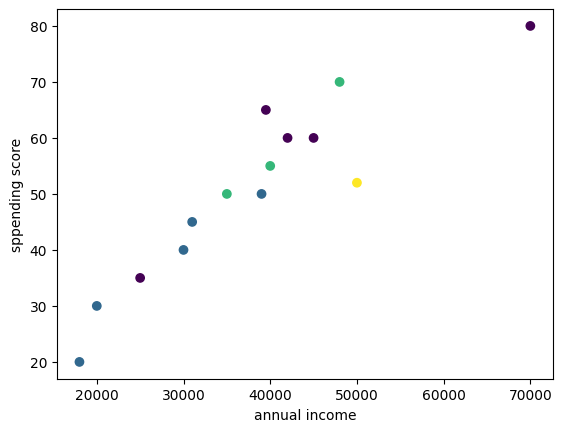

In [145]:
plt.scatter(df["annual_income"],df["spending_score"],c=clusters)
plt.xlabel("annual income")
plt.ylabel("sppending score")
plt.show()

In [129]:
# plt.plot(df["annual_income"],df["spending_score"])
# plt.xlabel("annual income")
# plt.ylabel("sppending score")
# # plt.show()

In [133]:
# sil_scores = []

# for k in range(2, 10):
#     model = KMeans(n_clusters=k)
#     labels = model.fit_predict(x_scaled)
    
#     score = silhouette_score(x_scaled, labels)
#     sil_scores.append(score)

#     print(f"k={k}, silhouette score={score}")

k=2, silhouette score=0.26218902021006396
k=3, silhouette score=0.28798804078656376
k=4, silhouette score=0.33340637084445
k=5, silhouette score=0.3312626544232879
k=6, silhouette score=0.3113616436716291
k=7, silhouette score=0.454539914109593
k=8, silhouette score=0.42515978576684443
k=9, silhouette score=0.49153837642407805


In [147]:
joblib.dump(model,"KMeans.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']